<a href="https://colab.research.google.com/github/AparajitPandit/AparajitPandit/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import mnist

In [2]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train=x_train/255
x_test=x_test/255

<function matplotlib.pyplot.show(close=None, block=None)>

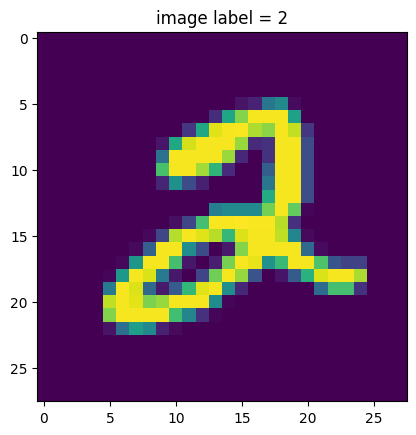

In [4]:
import matplotlib.pyplot as plt
plt.imshow(x_train[5])
plt.title(f"image label = {y_train[5]}")
plt.show

In [5]:
import numpy as np
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [6]:
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [7]:
model = Sequential([
    Flatten(input_shape=(28,28)),#input layer=784neuron
    Dense(12,activation='relu'),#hidden layer=12neuron
    Dense(10,activation='softmax')#output layer=10neuron
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
y_train=to_categorical(y_train,num_classes=10)


In [9]:
y_test=to_categorical(y_test,num_classes=10)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │         9,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,550 (37.30 KB)

 Trainable params: 9,550 (37.30 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [12]:
model.fit(x_train,y_train,batch_size=32,epochs=5,verbose=2)

Epoch 1/5
1875/1875 - 5s - 3ms/step - accuracy: 0.8588 - loss: 0.4871
Epoch 2/5
1875/1875 - 3s - 2ms/step - accuracy: 0.9191 - loss: 0.2822
Epoch 3/5
1875/1875 - 4s - 2ms/step - accuracy: 0.9271 - loss: 0.2545
Epoch 4/5
1875/1875 - 4s - 2ms/step - accuracy: 0.9317 - loss: 0.2378
Epoch 5/5
1875/1875 - 3s - 2ms/step - accuracy: 0.9353 - loss: 0.2253


In [13]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.2341
Test Accuracy: 0.9343


In [14]:
model.save('mnist.h5')

In [15]:
model.get_weights()

[array([[ 0.0289865 , -0.02716913,  0.05888958, ..., -0.01844969,
         -0.07865049, -0.01950163],
        [ 0.04660142, -0.00276313, -0.04983714, ...,  0.04863917,
         -0.05695571, -0.06235638],
        [-0.05453354, -0.06467143,  0.04540803, ..., -0.01737317,
          0.08151639,  0.07194019],
        ...,
        [-0.08379865,  0.07599864, -0.0658264 , ..., -0.03370428,
          0.04214544,  0.08614477],
        [-0.00890746, -0.06777286,  0.07451273, ..., -0.04798957,
         -0.04244544,  0.03947032],
        [ 0.00458115, -0.03275954,  0.02088262, ..., -0.03802639,
          0.00051163, -0.00392069]], dtype=float32),
 array([ 0.178874  ,  0.30561328,  0.17679809,  0.08237195, -0.34067073,
         0.22907475,  0.11166289, -0.53882617, -0.01759685,  0.18531507,
         0.5645288 ,  0.09500954], dtype=float32),
 array([[-5.80901086e-01, -7.45524704e-01, -4.56403673e-01,
         -2.81323612e-01,  3.65418702e-01,  1.96793973e-01,
         -9.77631330e-01,  6.96392894e-01